In [20]:
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import nan
from functions import * # import functions from the .py file

from pylab import rcParams
rcParams["figure.figsize"] = 16, 4

PAYLOADSIZE = 22

if PAYLOADSIZE % 2 != 0:
    print("Alarm! the payload size is not even.")
NUM_16RND = (PAYLOADSIZE-2)//2 # how many 16 bits random number included in each frame
MAX_SEQ = 256 # (decimal) maximum seq number defined by the length of the seq, the length of seq is 1B

## Log file

**For a fair comparison between groups, must follow the output format below**
<br>$\color{red}{\text{timestamp\_rx }| \text{ len [hex] } \text{ seq [hex] } \text{ payload [hex] }| \text{rssi} }$
<br>$\text{ len [hex]}$ = payload length + 1 (seq. field length [1B])
<br>$\text{ payload [hex]}$ should start with the pseudo sequence number [2B], indicates the starting byte's position in the file.
***
*Example log file output for one frame with reciever timestamp xxxx, frame length, seq number and random payload, received signal strength.*
<br>15:17:18.394 |0f 46 bd f8 f7 ea 41 ac 1b be 05 a0 7f d2 09 d4 |  -91 CRC error
<br>$\color{red}{\text{delimiter for four variables is "|" and delimiter for the payload each byte is the space " ".}}$

In [21]:
# define the file name
filename = "dump-25"
# import file to jupyter notebook
df = readfile("./results/32bit/" + filename + ".txt")
# check the imported data first 10 lines
df.head(10)


,index,time_rx,rssi,seq,payload
0,0,2026-04-28 11:35:47.627,-96,1,00 14 1a 56 22 e8 14 20 1f 30 25 19 1a 14 23 a...
1,1,2026-04-28 11:35:48.139,-97,3,00 3c 20 56 1c 27 1e 24 17 07 1a 80 27 e6 2a 9...
2,2,2026-04-28 11:35:48.659,-97,5,00 64 22 7b 2c 67 11 f6 1f a4 12 ef 22 26 29 7...
3,3,2026-04-28 11:35:48.929,-96,6,00 78 20 2d 2b f3 19 55 20 ab 09 69 0a 36 23 6...
4,4,2026-04-28 11:35:49.188,-98,7,00 8c 29 81 1d cf 22 4f 20 cd 31 6b 1d d7 14 3...
5,5,2026-04-28 11:35:49.697,-96,9,00 b4 1f b9 1d 5e 20 ef 2b 95 25 60 27 37 1f 9...
6,6,2026-04-28 11:35:50.218,-96,11,00 dc 1c e0 11 66 28 f0 1e 22 2d 5b 20 66 27 a...
7,7,2026-04-28 11:35:50.485,-96,12,00 f0 26 53 2f 37 1b cc 20 5d 21 a9 22 38 14 8...
8,8,2026-04-28 11:35:50.737,-96,13,01 04 16 b1 20 34 28 0e 1e 72 20 a5 23 da 1b 3...
9,9,2026-04-28 11:35:51.512,-95,16,01 40 1b cb 26 f9 28 6c 27 d3 2f 4a 18 bf 16 4...


In [22]:
# delete packets of invalid length (aka. error in length field at variable receiver length config) (PAYLOADSIZE + 2B pesudo sequence number)
test = df[df.payload.apply(lambda x: len(x)==((PAYLOADSIZE)*3-1))]
test.reset_index(inplace=True)

# Time

## Definition

**Evaluation metric**
<br>*File Transmission Time: the total latency that certain amount of Data $F$ is delivered to the destination.*
<br> $File\ Delay = Rx\_timestamp[N] - Rx\_timestamp[0]$
<br> where $N$ is the last packet
***
**Interesting to look at**:
<br>*Timestamp difference*: $\Delta T[i] = Rx\_timestamp[i] - Tx\_timestamp[i]$
1. *Worst-case packet delay*: the delay of the packet that takes the longest time to traverse.
2. *Packet delay variation*: the std of the packet delay.

In [23]:
# compute the file delay
file_delay = df.time_rx[len(df) - 1] - df.time_rx[0]
# convert the timedelta to s
file_delay_s = np.timedelta64(file_delay, "ms").astype(int) / 1000
print(f"The time it takes to transfer the file is : {file_delay}, which is {file_delay_s} seconds.")

The time it takes to transfer the file is : 0 days 00:01:17.279000, which is 77.279 seconds.


# Reliability

## Definition

**Evaluation metric**
<br>*Quality of data transfer.*
<br>*Bit Reliability*: The ratio of data bits correctly delivered to the data sink.
<br>*Bit Error Rate*: The ratio of data bits incorrectly delivered to the data sink.
$$Bit\ Reliability = 1 - BER = 1 - \frac{Number\ of\ wrong\ bit}{Total\ Number\ of\ bit\ received}$$
<br>*Achieved Data Rate*: The bit error rate is calculated based on the received data only. Missing packets do not affect the bit error rate, but are reflected in the achievable data rate.

## Statistics

In [24]:
# compute the BER for all received packets
# return the in total ber for received file, error statistics and correct file content supposed to be transmitted
ber = compute_ber(test, PACKET_LEN=NUM_16RND*2)
bit_reliability = (1-ber)*100
print(f"Bit error rate [%]: {(ber*100):.8f}\t\t(in received packets within pseudo sequence + payload) ")
if len(df) < 1:
    print("Data rate [bit/s]: More than one packet required for analysis.")
else:
    print(f"Data rate [bit/s]: {(len(df)*NUM_16RND*2/file_delay_s):.8f}\t\t(directly impacted by missed packets) ")

The total number of packets transmitted by the tag is 44.
Bit error rate [%]: 6.39051808		(in received packets within pseudo sequence + payload) 
Data rate [bit/s]: 51.50170163		(directly impacted by missed packets) 


Note: if individual packets have a high bit-error rate, it could be that the pseudo-sequence number was corrupted and the script could not identify the expected payload correctly.


Text(0.5, 0, 'Seq. Number')

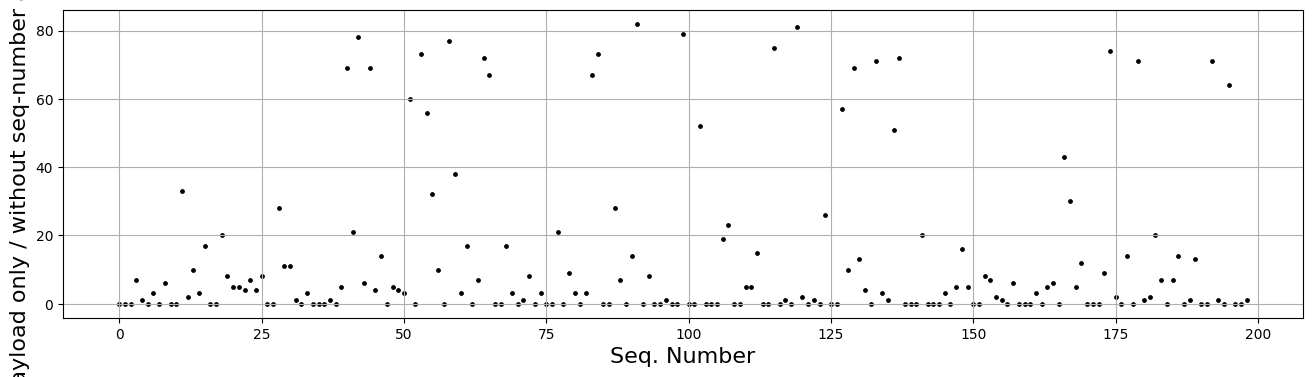

In [25]:
# BER for each packet
print("Note: if individual packets have a high bit-error rate, it could be that the pseudo-sequence number was corrupted and the script could not identify the expected payload correctly.")
plt.scatter(range(len(df)), [compute_ber_packet(row,PACKET_LEN=NUM_16RND*2)[0] for (_,row) in df.iterrows()], marker='o', s=6, color='black')
plt.grid()
plt.ylabel('Bit Error Rate [%] (payload only / without seq-number and pseudo-seq-number)', fontsize=16)
plt.xlabel('Seq. Number', fontsize=16)

# Packet error rate calculation

In [26]:
per = compute_per(test, PACKET_LEN=NUM_16RND * 2)
packet_reliability = (1 - per) * 100

print(f"Packet error rate [%]: {(per * 100):.8f}")
print(f"Packet reliability [%]: {packet_reliability:.8f}")

Packet error rate [%]: 57.52688172
Packet reliability [%]: 42.47311828


## Burst Error Analysis

A **burst** is a consecutive run of packets that all contain at least one bit error.
The plots below show how long these bursts are and where they occur.
Long bursts justify the use of interleaving — FEC alone cannot correct a burst
that overwhelms multiple codewords in the same packet.

Total packets analysed : 186
Packets with errors    : 107 (57.5%)
Error burst runs       : 48
  Max burst length     : 7 packets
  Mean burst length    : 2.2 packets
Clean runs             : 48
  Max clean run        : 6 packets


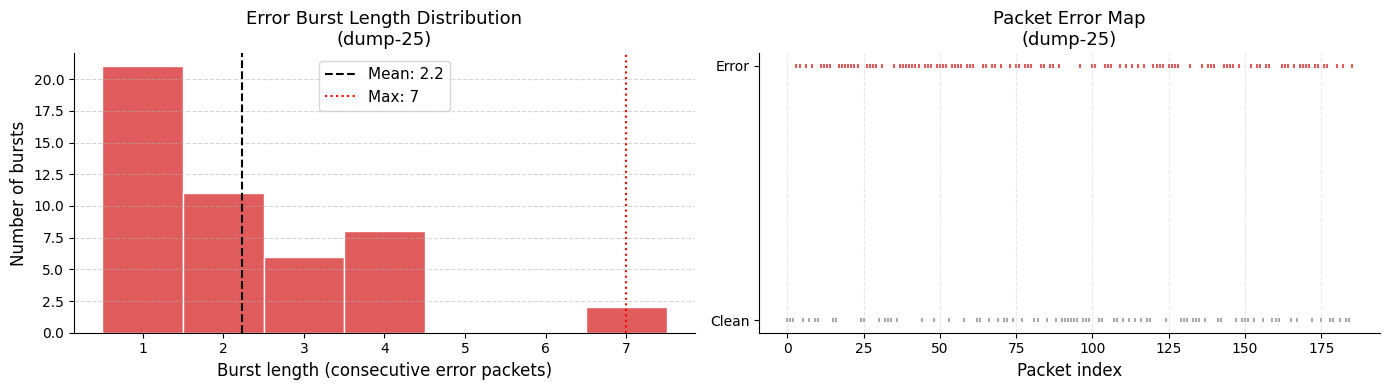

Max burst of 7 packets — interleaving depth should be >= 7 to fully break up bursts.


In [27]:
# ── Compute burst runs ────────────────────────────────────────────────────────
burst_packet_len = NUM_16RND * 2

error_flags = []
for _, row in test.iterrows():
    errors, _ = compute_ber_packet(row, PACKET_LEN=burst_packet_len)
    error_flags.append(1 if errors > 0 else 0)

# Group into runs of consecutive 0s and 1s
runs = []
current_val = error_flags[0]
current_len = 1
for flag in error_flags[1:]:
    if flag == current_val:
        current_len += 1
    else:
        runs.append((current_len, current_val))
        current_val = flag
        current_len = 1
runs.append((current_len, current_val))

error_runs = [l for l, e in runs if e == 1]
clean_runs = [l for l, e in runs if e == 0]

print(f'Total packets analysed : {len(error_flags)}')
print(f'Packets with errors    : {sum(error_flags)} ({sum(error_flags)/len(error_flags)*100:.1f}%)')
print(f'Error burst runs       : {len(error_runs)}')
print(f'  Max burst length     : {max(error_runs) if error_runs else 0} packets')
print(f'  Mean burst length    : {sum(error_runs)/len(error_runs):.1f} packets' if error_runs else '  No error bursts.')
print(f'Clean runs             : {len(clean_runs)}')
print(f'  Max clean run        : {max(clean_runs) if clean_runs else 0} packets')

# ── Plot 1: burst length histogram ───────────────────────────────────────────
if error_runs:
    max_burst = max(error_runs)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(error_runs, bins=range(1, max_burst + 2),
                 color='#E05C5C', edgecolor='white', align='left')
    axes[0].axvline(sum(error_runs)/len(error_runs), color='black',
                    linestyle='--', label=f'Mean: {sum(error_runs)/len(error_runs):.1f}')
    axes[0].axvline(max_burst, color='red', linestyle=':',
                    label=f'Max: {max_burst}')
    axes[0].set_xlabel('Burst length (consecutive error packets)', fontsize=12)
    axes[0].set_ylabel('Number of bursts', fontsize=12)
    axes[0].set_title(f'Error Burst Length Distribution\n({filename})', fontsize=13)
    axes[0].legend(fontsize=11)
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # ── Plot 2: packet-by-packet error map ───────────────────────────────────
    axes[1].scatter(
        range(len(error_flags)),
        error_flags,
        c=['#E05C5C' if e else '#AAAAAA' for e in error_flags],
        s=10, marker='|'
    )
    axes[1].set_xlabel('Packet index', fontsize=12)
    axes[1].set_yticks([0, 1])
    axes[1].set_yticklabels(['Clean', 'Error'])
    axes[1].set_title(f'Packet Error Map\n({filename})', fontsize=13)
    axes[1].grid(axis='x', linestyle='--', alpha=0.3)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
    print(f'Max burst of {max_burst} packets — interleaving depth should be >= {max_burst} to fully break up bursts.')


## Byte Error Distribution

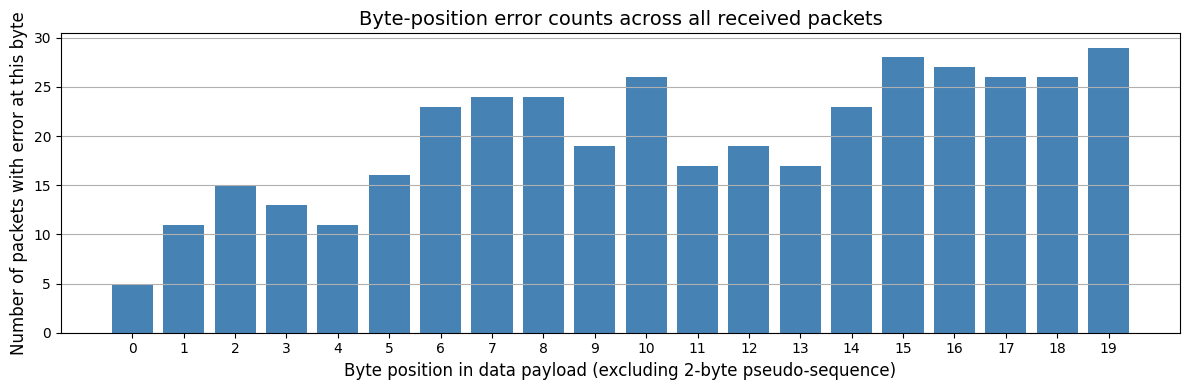

Valid packets used: 169


In [28]:
PACKET_LEN = NUM_16RND * 2

byte_error_counts = np.zeros(PACKET_LEN, dtype=int)
valid_packets_used = 0

for _, row in test.iterrows():
    vec = byte_error_vector(row, PACKET_LEN=PACKET_LEN)
    if vec is not None:
        byte_error_counts += vec
        valid_packets_used += 1

if valid_packets_used == 0:
    print("No valid packets available for byte-position analysis.")
else:
    plt.figure(figsize=(12, 4))
    plt.bar(range(PACKET_LEN), byte_error_counts, color='steelblue')
    plt.grid(axis='y')
    plt.xlabel("Byte position in data payload (excluding 2-byte pseudo-sequence)", fontsize=12)
    plt.ylabel("Number of packets with error at this byte", fontsize=12)
    plt.title("Byte-position error counts across all received packets", fontsize=14)
    plt.xticks(range(PACKET_LEN))
    plt.tight_layout()
    plt.show()
    print(f"Valid packets used: {valid_packets_used}")


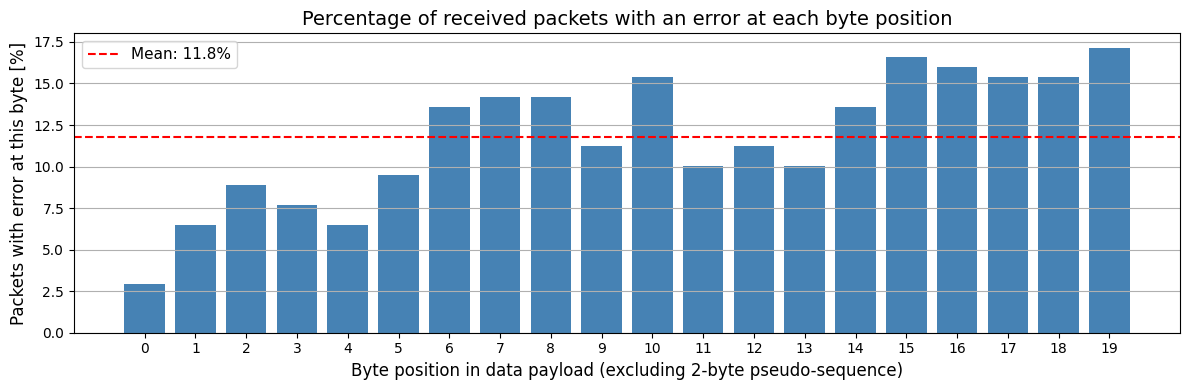

In [29]:
# Same data as above but expressed as a percentage
byte_error_percent = byte_error_counts / valid_packets_used * 100

plt.figure(figsize=(12, 4))
plt.bar(range(PACKET_LEN), byte_error_percent, color='steelblue')
plt.axhline(byte_error_percent.mean(), color='red', linestyle='--', label=f'Mean: {byte_error_percent.mean():.1f}%')
plt.grid(axis='y')
plt.xlabel("Byte position in data payload (excluding 2-byte pseudo-sequence)", fontsize=12)
plt.ylabel("Packets with error at this byte [%]", fontsize=12)
plt.title("Percentage of received packets with an error at each byte position", fontsize=14)
plt.xticks(range(PACKET_LEN))
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


## FEC-Decoded Packet Error Rate

The cells below apply the Hamming(7,4) decoder to received packets and measure
how many packets are fully corrected.  
**Note:** this section requires data captured with the FEC-enabled firmware.  
For baseline (non-FEC) data the decoded PER will not be meaningful.

In [30]:
# DATA_LEN must match the value used when the firmware was compiled (12, 20, or 52)
DATA_LEN = PAYLOADSIZE - 2

per_fec = compute_per_fec(test, DATA_LEN=DATA_LEN)
per_baseline = compute_per(test, PACKET_LEN=DATA_LEN)

print(f"PER without FEC decoding : {per_baseline * 100:.4f}%")
print(f"PER with FEC decoding    : {per_fec     * 100:.4f}%")
print(f"Improvement              : {(per_baseline - per_fec) * 100:.4f} percentage points")


PER without FEC decoding : 57.5269%
PER with FEC decoding    : 100.0000%
Improvement              : -42.4731 percentage points


## FEC + Interleaving Packet Error Rate

The cell below de-interleaves the received block, applies Hamming(7,4) decoding,
and measures how many of the reconstructed original packets still contain errors.

**Note:** this section requires data captured with `USE_FEC=1` and `USE_INTERLEAVING=1`.
Each received packet payload must be exactly `INTERLEAVE_ROWS` (64) bytes.
For baseline or FEC-only captures this cell will report no complete blocks found.

In [31]:
# DATA_LEN must match the firmware compile setting (12, 20, or 52)
DATA_LEN = PAYLOADSIZE - 2
INTERLEAVE_ROWS = 64  # must match INTERLEAVE_ROWS in interleaver.h

per_il = compute_per_fec_interleaved(test, DATA_LEN=DATA_LEN, INTERLEAVE_ROWS=INTERLEAVE_ROWS)

print(f"PER baseline (no FEC, no IL) : {compute_per(test, PACKET_LEN=DATA_LEN) * 100:.4f}%")
print(f"PER FEC only                 : {compute_per_fec(test, DATA_LEN=DATA_LEN) * 100:.4f}%")
print(f"PER FEC + Interleaving       : {per_il * 100:.4f}%")
print(f"Improvement (FEC vs FEC+IL)  : {(compute_per_fec(test, DATA_LEN=DATA_LEN) - per_il) * 100:.4f} percentage points")

PER baseline (no FEC, no IL) : 57.5269%
PER FEC only                 : 100.0000%
PER FEC + Interleaving       : 100.0000%
Improvement (FEC vs FEC+IL)  : 0.0000 percentage points


# Distance

## Definition

**The communication distance of the system.**
<br>$D_{1}$: the distance between carrier<->backscatter_tag[m]
<br>$D_{2}$: the distance between backscatter_tag<->receiver[m]
<br> Distance metric = $D_{1}^2D_{2}^2$
<br>

In [32]:
# record the distance
dis_carrier_tag = 1
dis_tag_rx = 4

dis_metric = dis_carrier_tag**2*dis_tag_rx**2
print(f"Distance metric is: {dis_metric}")

Distance metric is: 16


# Radarplot

**Please pay attention to the unit**
<br> <font color='red'>Time</font>: use second as unit
<br> <font color='red'>Reliability</font>: use the percent as unit
<br> <font color='red'>Distance</font>: use meter as unit
<br>**Metics = [Time(s), Reliability(%), Distance(m)]**
<br> <font color='red'>Always keep the reference in your plot.</font>
<br> Tips: for ploting, time metric uses $\frac{1}{Time}*1000$ as the time metric, the higher the value the better the system performance

[np.float64(77.279), 93.60948191593353, 16]


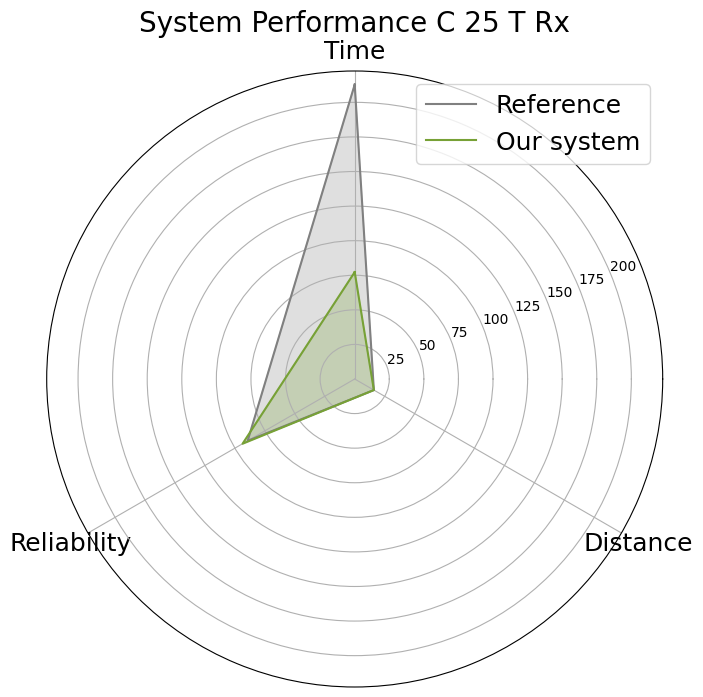

In [33]:
metrics = [file_delay_s, bit_reliability, dis_metric]

system_ref_baseline_c25 = [57.284, 96.41, 16] # C ->(25cm) Tag
system_ref_baseline_c50 = [np.float64(100.318), 92.21428571428572, 16] # C ->(50cm) Tag
system_ref_baseline_middle = [0, 0, 0] # C -> (150) Tag -> (150) Receiver
system_ref_baseline_rx50 = [np.float64(212.826), 89.36160714285715, 16] # Tag ->(50cm) Receiver
system_ref_baseline_rx25 = [np.float64(121.055), 91.36607142857143, 16] # # Tag ->(25cm) Receiver


print(metrics)
#                                                 25cm                            3m
title = "System Performance C 25 T Rx" # Carrier ------> Tag -> Receiver (Carrier --> Receiver)
radar_plot(metrics, system_ref=system_ref_baseline_rx50, title=title)